# Install

In [ ]:
%%bash
git clone https://github.com/huggingface/diffusers
cd diffusers

pip install .
cd examples/dreambooth
pip install -q -r requirements.txt

pip install -q accelerate transformers tensorboard ftfy xformers bitsandbytes

Processing /content/diffusers
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
  Created wheel for diffusers: filename=diffusers-0.38.0.dev0-py3-none-any.whl size=5099543 sha256=55cd49852d2c8e59b404309761d003fa89f78414e6fa811e9c3a2a2a437cd9fe
  Stored in directory: /tmp/pip-ephem-wheel-cache-6_m6qigf/wheels/8a/fc/09/385efb77b455b2fd4a656c950079c93147e1f50ae614e51beb
Successfully built diffusers
  Attempting uninstall: diffusers
    Found existing installation: diffusers 0.37.0
    Uninstalling diffusers-0.37.0:
      Successfully uninstalled diffusers-0.37.0
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 168.3/168.3 kB 11.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 3.1 MB/s eta 0:0

Cloning into 'diffusers'...


In [ ]:
!pip install -U accelerate diffusers datasets transformers peft bitsandbytes xformers

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 527.0/527.0 kB 44.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 137.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 557.0/557.0 kB 52.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.6/47.6 MB 44.1 MB/s eta 0:00:00
  Attempting uninstall: pyarrow
    Found existing installation: pyarrow 18.1.0
    Uninstalling pyarrow-18.1.0:
      Successfully uninstalled pyarrow-18.1.0
  Attempting uninstall: datasets
    Found existing installation: datasets 4.0.0
    Uninstalling datasets-4.0.0:
      Successfully uninstalled datasets-4.0.0
  Attempting uninstall: transformers
    Found existing installation: transformers 5.0.0
    Uninstalling transformers-5.0.0:
      Successfully uninstalled transformers-5.0.0
  Attempting uninstall: peft
    Found existing installation: peft 0.7.0
    Uninstalling peft-0.7.0:
      Successfully uninstalled peft-0.7.0


# LoRA Fine-tuning

In [ ]:
instance_data_dir = "/content/diffusers/images"
output_dir = "/content/my_lora_model"
instance_prompt = "a photo of hbr mari_satsuki"

!accelerate launch diffusers/examples/dreambooth/train_dreambooth_lora.py \
  --pretrained_model_name_or_path="runwayml/stable-diffusion-v1-5" \
  --instance_data_dir="$instance_data_dir" \
  --output_dir="$output_dir" \
  --instance_prompt="$instance_prompt" \
  --resolution=512 \
  --train_batch_size=2 \
  --gradient_accumulation_steps=1 \
  --learning_rate=5e-5 \
  --lr_scheduler="constant" \
  --lr_warmup_steps=0 \
  --max_train_steps=500 \
  --mixed_precision="fp16" \
  --train_text_encoder \
  --gradient_checkpointing \
  --use_8bit_adam

The following values were not passed to `accelerate launch` and had defaults used instead:
	`--num_processes` was set to a value of `1`
	`--num_machines` was set to a value of `1`
	`--mixed_precision` was set to a value of `'no'`
	`--dynamo_backend` was set to a value of `'no'`
To avoid this warning pass in values for each of the problematic parameters or run `accelerate config`.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
tokenizer_config.json: 100% 806/806 [00:00<00:00, 4.14MB/s]
vocab.json: 1.06MB [00:00, 114MB/s]
merges.txt: 525kB [00:00, 113MB/s]
special_tokens_map.json: 100% 472/472 [00:00<00:00, 2.32MB/s]
config.json: 100% 617/617 [00:00<00:00, 2.86MB/s]
You are using a model of type `clip_text_model` to instantiate a model of ty

# Inference for evaluation

In [1]:
import torch
from diffusers import StableDiffusionPipeline

output_dir = "/content/my_lora_model"

pipe = StableDiffusionPipeline.from_pretrained(
    "runwayml/stable-diffusion-v1-5",
    torch_dtype=torch.float16
).to("cuda")

pipe.load_lora_weights(output_dir)

Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

CLIPTextModel LOAD REPORT from: /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-v1-5/snapshots/451f4fe16113bff5a5d2269ed5ad43b0592e9a14/text_encoder
Key                                | Status     |  | 
-----------------------------------+------------+--+-
text_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/396 [00:00<?, ?it/s]

StableDiffusionSafetyChecker LOAD REPORT from: /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-v1-5/snapshots/451f4fe16113bff5a5d2269ed5ad43b0592e9a14/safety_checker
Key                                               | Status     |  | 
--------------------------------------------------+------------+--+-
vision_model.vision_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/96 [00:00<?, ?it/s]

In [5]:
prompt1 = "a photo of hbr mari_satsuki"
prompt2 = "a photo of hbr mari_satsuki running on a sandy beach, ocean waves in the background, golden hour"
prompt3 = "a photo of hbr mari_satsuki sitting on a city street at night, neon signs, wet pavement reflections"
prompt4 = "a photo of hbr mari_satsuki in a snowy forest, pine trees covered with snow, soft sunlight"
prompt5 = "a photo of hbr mari_satsuki made of stained glass, intricate patterns, sunlight shining through"
prompt6 = "a photo of hbr mari_satsuki with a red sunglasses, cool pose, summer vibe"
prompt7 = "a photo of hbr mari_satsuki wearing a tiny wizard hat, holding a wooden staff, magical forest background"
prompt8 = "a painting of hbr mari_satsuki in the style of Van Gogh, thick brushstrokes"
prompt9 = "a watercolor illustration of hbr mari_satsuki, soft pastel colors, loose brushwork"
prompt10 = "a cyberpunk portrait of hbr mari_satsuki, neon lights, futuristic city, digital art"
image = pipe(prompt1, num_inference_steps=50, guidance_scale=7.5).images[0]
image.save("test-1.png")

  0%|          | 0/50 [00:00<?, ?it/s]

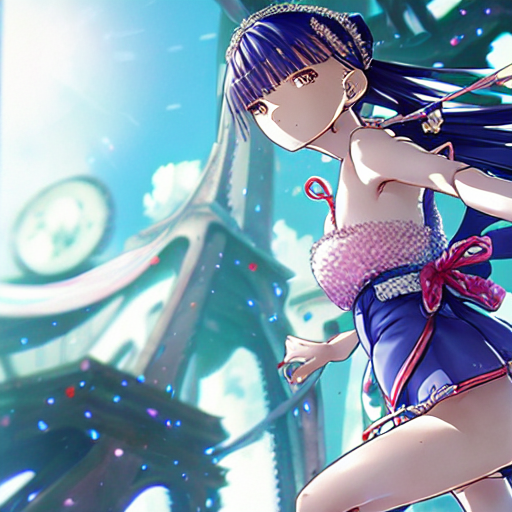

In [6]:
# show image
display(image)

# Diversity check with lpips

In [ ]:
!pip install lpips

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.8/53.8 kB 9.4 MB/s eta 0:00:00


In [ ]:
import torch
import gc
import lpips
import numpy as np
from diffusers import StableDiffusionPipeline
from PIL import Image

lpips_model = lpips.LPIPS(net='alex').eval().cuda()

def generate_images(prompt, num_images=4, seed=None):
    images = []
    for i in range(num_images):
        if seed is not None:
            generator = torch.Generator(device="cuda").manual_seed(seed + i)
        else:
            generator = None

        with torch.no_grad():
            img = pipe(
                prompt,
                num_inference_steps=50,
                guidance_scale=7.5,
                generator=generator
            ).images[0]

        images.append(img)
        torch.cuda.empty_cache()
    return images

def pil_to_tensor(img):
    img = np.array(img).astype(np.float32) / 127.5 - 1.0   # [-1, 1]
    img = torch.from_numpy(img).permute(2, 0, 1).unsqueeze(0)  # (1,3,H,W)
    return img.cuda()


prompt = "a photo of hbr mari_satsuki wearing a tiny wizard hat, holding a wooden staff, magical forest background"
images = generate_images(prompt, num_images=4)

#  compute
distances = []
for i in range(len(images)):
    for j in range(i+1, len(images)):
        img_i = pil_to_tensor(images[i])
        img_j = pil_to_tensor(images[j])
        with torch.no_grad():
            d = lpips_model(img_i, img_j).item()
        distances.append(d)
        del img_i, img_j
        torch.cuda.empty_cache()

mean_lpips = np.mean(distances)
std_lpips = np.std(distances)
print(f"average LPIPS: {mean_lpips:.4f}")
print(f"std: {std_lpips:.4f}")
print(f"min/max: {np.min(distances):.4f} / {np.max(distances):.4f}")

for idx, img in enumerate(images):
    img.save(f"generated_{idx}.png")

Setting up [LPIPS] perceptual loss: trunk [alex], v[0.1], spatial [off]
Loading model from: /usr/local/lib/python3.12/dist-packages/lpips/weights/v0.1/alex.pth


  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

average LPIPS: 0.6747
std: 0.0461
min/max: 0.6157 / 0.7480
